# CNN Latency Benchmark Notebook

This notebook benchmarks CNN inference speed using the 2025 test dataset.
It samples 100 random input sequences and measures prediction latency.

In [21]:
import os
import matplotlib.pyplot as plt
import json
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from datetime import datetime
import sys

sys.path.append('..')
from data_loader import DataLoader

# Configuration

In [22]:
MODEL_CONFIG = {
    'CNN': {
        'model_path': 'carbon_model_cnn_v3.tflite',
        'scaler_path': 'scaler_params_cnn_v3.json',
        'window_size': 24,
        'features': ['Carbon intensity gCO₂eq/kWh (Life cycle)', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos'],
    }
}

TARGET_COL = 'Carbon intensity gCO₂eq/kWh (Life cycle)'
BENCHMARK_SAMPLES = 100
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

# Helper Functions

In [23]:
def load_scaler_params(path):
    """Load scaler parameters from JSON."""
    with open(path, 'r') as f:
        return json.load(f)

def create_sequences(data, window_size):
    """Create sequences of length window_size from data."""
    x = []
    for i in range(len(data) - window_size + 1):
        x.append(data[i:i + window_size])
    return np.array(x)

def scale_target(data, scaler_params):
    """Scale target using target_mean and target_scale."""
    return (data - scaler_params['target_mean']) / scaler_params['target_scale']

def scale_features(data, scaler_params):
    """Scale features using feature_mean and feature_scale."""
    return (data - scaler_params['feature_mean']) / scaler_params['feature_scale']

def create_time_features(df):
    """Create cyclical time features (hour_sin, hour_cos, year_sin, year_cos)."""
    df = df.copy()

    # Hour of day (0-23)
    df['hour_sin'] = np.sin(2 * np.pi * df['Datetime (UTC)'].dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['Datetime (UTC)'].dt.hour / 24)

    # Day of year (0-365)
    df['year_sin'] = np.sin(2 * np.pi * df['Datetime (UTC)'].dt.dayofyear / 365)
    df['year_cos'] = np.cos(2 * np.pi * df['Datetime (UTC)'].dt.dayofyear / 365)

    return df

# Load Data

In [24]:
loader = DataLoader()
df = loader.load_emissions()

# Filter for 2025 only (the most recent complete year in your dataset)
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])
test_df = df[df['Datetime (UTC)'].dt.year == 2025].copy()

print(f"\nLoaded {len(test_df)} rows from 2025")
print(f"  Date range: {test_df['Datetime (UTC)'].min()} to {test_df['Datetime (UTC)'].max()}")

# Create time features
test_df = create_time_features(test_df)

print(f"\nCreated time features")
print(f"  Columns: {list(test_df.columns)}")

Emissions: 43824 rows, 2021-01-01 00:00:00 to 2025-12-31 23:00:00
Columns: ['Datetime (UTC)', 'Country', 'Zone name', 'Zone id', 'Carbon intensity gCO₂eq/kWh (direct)', 'Carbon intensity gCO₂eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)', 'Renewable energy percentage (RE%)', 'Data source', 'Data estimated', 'Data estimation method']

Loaded 8760 rows from 2025
  Date range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00

Created time features
  Columns: ['Datetime (UTC)', 'Country', 'Zone name', 'Zone id', 'Carbon intensity gCO₂eq/kWh (direct)', 'Carbon intensity gCO₂eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)', 'Renewable energy percentage (RE%)', 'Data source', 'Data estimated', 'Data estimation method', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos']


# Load Model and Scaler Parameters

In [25]:
config = MODEL_CONFIG['CNN']
scaler_params = load_scaler_params(config['scaler_path'])

print(f"\nScaler parameters loaded")
print(f"  Target mean: {scaler_params['target_mean']}")
print(f"  Target scale: {scaler_params['target_scale']}")
print(f"  Feature names: {scaler_params['feature_names']}")

# Load TFLite interpreter
interpreter = tf.lite.Interpreter(model_path=config['model_path'])
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"\nTFLite model loaded: {config['model_path']}")
print(f"  Input shape: {input_details[0]['shape']}")
print(f"  Output shape: {output_details[0]['shape']}")


Scaler parameters loaded
  Target mean: [119.10597070015221]
  Target scale: [63.878611437114415]
  Feature names: ['hour_sin', 'hour_cos', 'year_sin', 'year_cos']

TFLite model loaded: carbon_model_cnn_v3.tflite
  Input shape: [ 1 24  5]
  Output shape: [ 1 24]


C:\Users\jbro9\Desktop\SDU\Semester 2\eris\MAJJ-ADL-eris\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


# Prepare Sequences for Benchmarking

In [26]:
# Get features (target + time features)
X_raw = test_df[config['features']].astype(np.float32).values

# Scale: separate scaling for target (col 0) and features (cols 1+)
X_scaled = X_raw.copy()
X_scaled[:, 0] = scale_target(X_raw[:, 0], scaler_params)
X_scaled[:, 1:] = scale_features(X_raw[:, 1:], scaler_params)

# Create sequences
X_seq = create_sequences(X_scaled, config['window_size'])

print(f"\nCreated {len(X_seq)} sequences")
print(f"  Sequence shape: {X_seq.shape}")
print(f"  Example sequence (first row, first 5 time steps, all 5 features):")
print(f"  {X_seq[0][:5]}")


Created 8737 sequences
  Sequence shape: (8737, 24, 5)
  Example sequence (first row, first 5 time steps, all 5 features):
  [[-8.5374385e-01  2.3706723e-17  1.4142135e+00  2.4343362e-02
   1.4140040e+00]
 [-9.4031429e-01  3.6602539e-01  1.3660253e+00  2.4343362e-02
   1.4140040e+00]
 [-9.6317011e-01  7.0710677e-01  1.2247448e+00  2.4343362e-02
   1.4140040e+00]
 [-1.0229710e+00  1.0000000e+00  1.0000000e+00  2.4343362e-02
   1.4140040e+00]
 [-1.0251627e+00  1.2247448e+00  7.0710677e-01  2.4343362e-02
   1.4140040e+00]]


# Sample 100 random sequences for benchmarking

In [27]:
if len(X_seq) < BENCHMARK_SAMPLES:
    print(f"\nOnly {len(X_seq)} sequences available, using all.")
    sample_indices = np.arange(len(X_seq))
else:
    sample_indices = np.random.choice(len(X_seq), BENCHMARK_SAMPLES, replace=False)

sample_sequences = X_seq[sample_indices]

print(f"\nSampled {len(sample_sequences)} sequences")
print(f"  Seed: {RANDOM_SEED}")
print(f"  Sample indices (first 10): {sorted(sample_indices)[:10]}")


Sampled 100 sequences
  Seed: 42
  Sample indices (first 10): [np.int32(14), np.int32(80), np.int32(95), np.int32(221), np.int32(222), np.int32(321), np.int32(360), np.int32(429), np.int32(453), np.int32(509)]


# Warm-up run (to load model into memory and avoid cold start latency)

In [28]:
warm_up_sample = sample_sequences[0:1].astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], warm_up_sample)
interpreter.invoke()
warmup_out = interpreter.get_tensor(output_details[0]['index'])

print(f"\nWarm-up complete")
print(f"  Output shape: {warmup_out.shape}")
print(f"  Sample output (first 5 timesteps): {warmup_out[0][:5]}")


Warm-up complete
  Output shape: (1, 24)
  Sample output (first 5 timesteps): [0.8103691  0.86061895 0.92034453 0.93191624 0.89691424]


# Benchmark: Single-sample inference

In [29]:
latencies = []

for i, sample in enumerate(sample_sequences):
    sample_batch = sample[np.newaxis, ...].astype(np.float32)  # Add batch dim

    start = time.perf_counter()
    interpreter.set_tensor(input_details[0]['index'], sample_batch)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    elapsed = time.perf_counter() - start

    latencies.append(elapsed)

    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{len(sample_sequences)} samples")

latencies = np.array(latencies) * 1000  # Convert to milliseconds

print(f"\nSingle-sample inference benchmark complete")
print(f"  Total samples: {len(latencies)}")
print(f"  Total time: {latencies.sum():.2f} ms ({latencies.sum() / 1000:.2f} s)")

  Processed 20/100 samples
  Processed 40/100 samples
  Processed 60/100 samples
  Processed 80/100 samples
  Processed 100/100 samples

Single-sample inference benchmark complete
  Total samples: 100
  Total time: 0.71 ms (0.00 s)


# Benchmark: Batch inference

In [30]:
batch_sizes = [1, 10, 50, 100]
batch_results = {}

for batch_size in batch_sizes:
    if batch_size > len(sample_sequences):
        continue

    # Create batches
    n_batches = len(sample_sequences) // batch_size
    batches = [sample_sequences[i*batch_size:(i+1)*batch_size] for i in range(n_batches)]

    if not batches:
        continue

    batch_latencies = []

    for batch in batches:
        # Process each sample in the batch individually (model only accepts batch_size=1)
        batch_time = 0
        for sample in batch:
            sample_data = sample[np.newaxis, ...].astype(np.float32)  # Shape: (1, 24, 5)

            start = time.perf_counter()
            interpreter.set_tensor(input_details[0]['index'], sample_data)
            interpreter.invoke()
            output = interpreter.get_tensor(output_details[0]['index'])
            batch_time += time.perf_counter() - start

        # Per-sample latency within the batch
        batch_latencies.append((batch_time * 1000) / len(batch))

    batch_results[batch_size] = {
        'per_sample_ms': np.mean(batch_latencies),
        'std_ms': np.std(batch_latencies),
        'min_ms': np.min(batch_latencies),
        'max_ms': np.max(batch_latencies),
    }

    print(f"  Batch size {batch_size:3d}: {batch_results[batch_size]['per_sample_ms']:.3f} ± {batch_results[batch_size]['std_ms']:.3f} ms/sample")

  Batch size   1: 0.006 ± 0.006 ms/sample
  Batch size  10: 0.007 ± 0.001 ms/sample
  Batch size  50: 0.005 ± 0.000 ms/sample
  Batch size 100: 0.005 ± 0.000 ms/sample


# Summary of Results

In [31]:
results = {
    'timestamp': datetime.now().isoformat(),
    'model': config['model_path'],
    'dataset': '2025 test set',
    'samples': int(len(latencies)),
    'single_sample': {
        'count': int(len(latencies)),
        'total_ms': float(latencies.sum()),
        'total_s': float(latencies.sum() / 1000),
        'mean_ms': float(np.mean(latencies)),
        'median_ms': float(np.median(latencies)),
        'std_ms': float(np.std(latencies)),
        'min_ms': float(np.min(latencies)),
        'max_ms': float(np.max(latencies)),
        'p95_ms': float(np.percentile(latencies, 95)),
        'p99_ms': float(np.percentile(latencies, 99)),
    },
    'batch_inference': batch_results,
}

# Display summary
print(f"\nSingle-Sample Inference (n={len(latencies)}):")
print(f"   Total time:  {results['single_sample']['total_s']:.2f} s")
print(f"   Mean latency: {results['single_sample']['mean_ms']:.3f} ms")
print(f"   Median:      {results['single_sample']['median_ms']:.3f} ms")
print(f"   Std dev:     {results['single_sample']['std_ms']:.3f} ms")
print(f"   Min:         {results['single_sample']['min_ms']:.3f} ms")
print(f"   Max:         {results['single_sample']['max_ms']:.3f} ms")
print(f"   P95:         {results['single_sample']['p95_ms']:.3f} ms")
print(f"   P99:         {results['single_sample']['p99_ms']:.3f} ms")

if batch_results:
    print(f"\nBatch Inference:")
    for batch_size, metrics in sorted(batch_results.items()):
        print(f"   Batch {batch_size:3d}: {metrics['per_sample_ms']:.3f} ± {metrics['std_ms']:.3f} ms/sample")

# Save results to JSON
output_file = f"cnn_benchmark_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(output_file, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n Results saved to {output_file}")


Single-Sample Inference (n=100):
   Total time:  0.00 s
   Mean latency: 0.007 ms
   Median:      0.006 ms
   Std dev:     0.006 ms
   Min:         0.005 ms
   Max:         0.064 ms
   P95:         0.010 ms
   P99:         0.027 ms

Batch Inference:
   Batch   1: 0.006 ± 0.006 ms/sample
   Batch  10: 0.007 ± 0.001 ms/sample
   Batch  50: 0.005 ± 0.000 ms/sample
   Batch 100: 0.005 ± 0.000 ms/sample

 Results saved to cnn_benchmark_results_20260516_132731.json


# Visualisation of Latencies

C:\Users\jbro9\AppData\Local\Temp\ipykernel_44324\2929641785.py:38: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


 Plots saved to cnn_benchmark_plots_20260516_132731.png


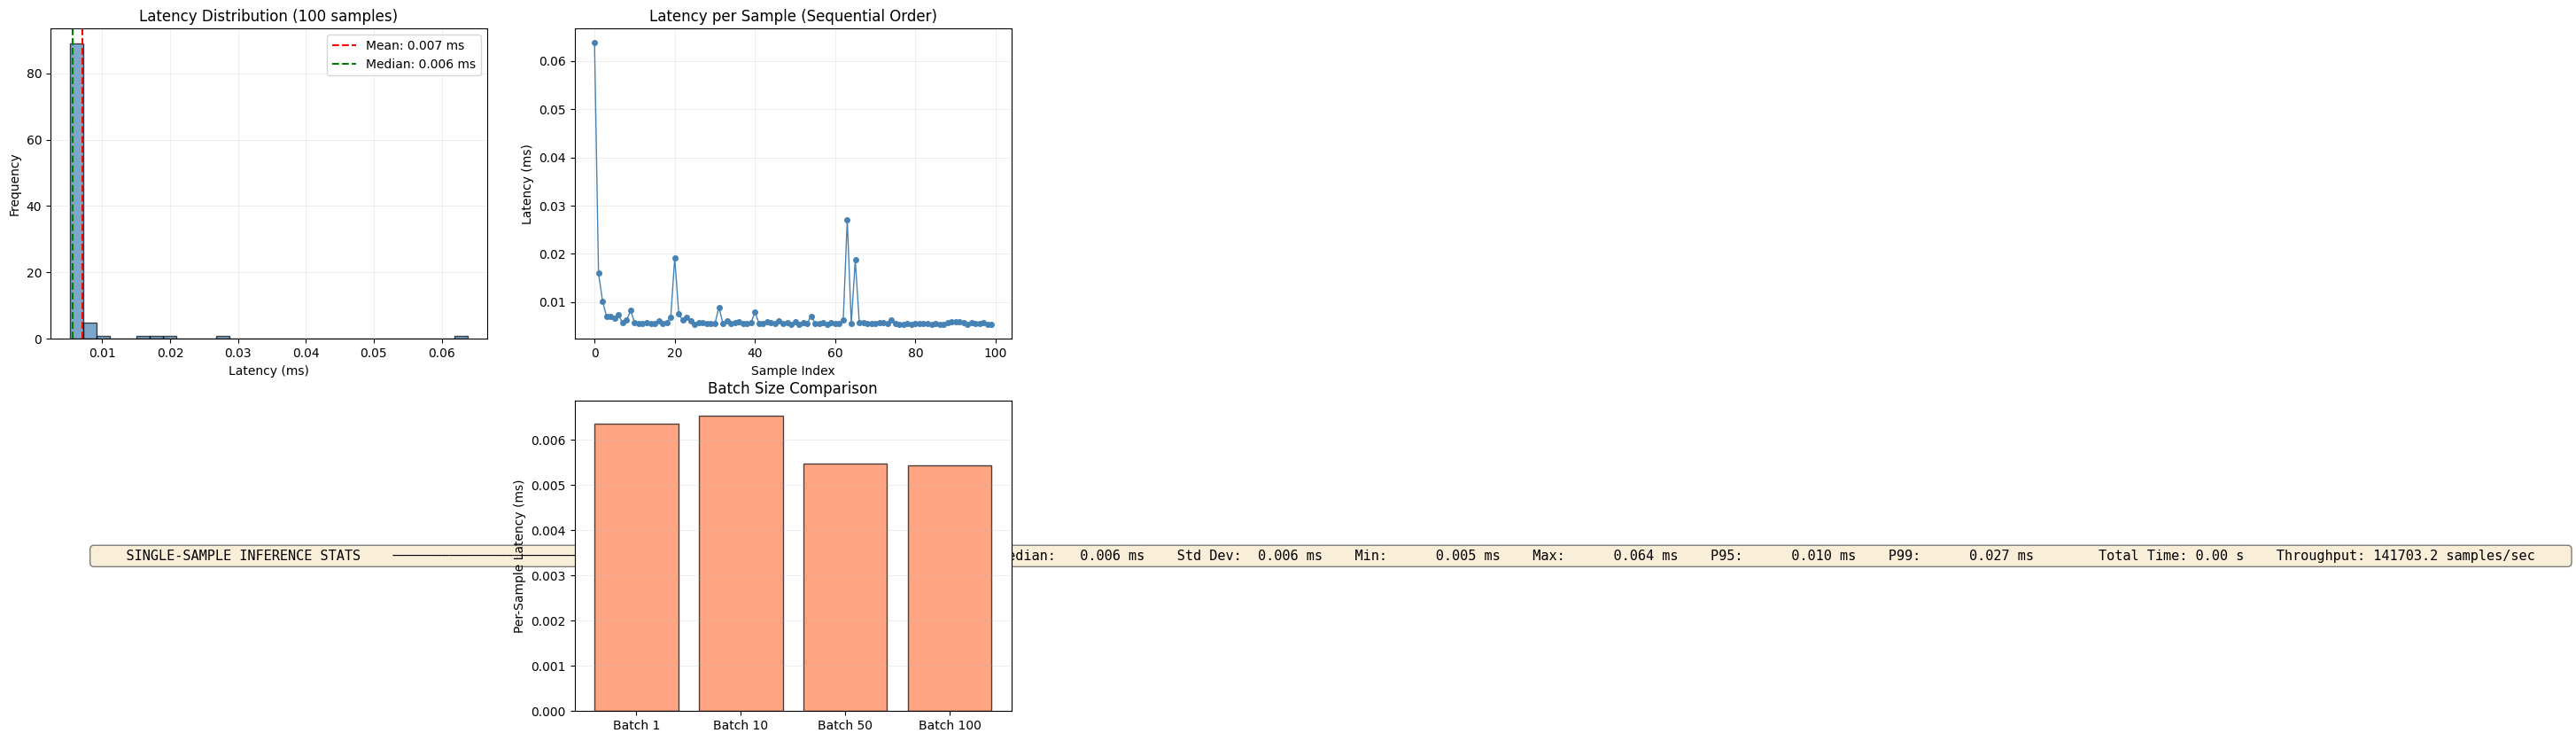

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Latency distribution
axes[0, 0].hist(latencies, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(np.mean(latencies), color='red', linestyle='--', label=f'Mean: {np.mean(latencies):.3f} ms')
axes[0, 0].axvline(np.median(latencies), color='green', linestyle='--', label=f'Median: {np.median(latencies):.3f} ms')
axes[0, 0].set_xlabel('Latency (ms)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Latency Distribution (100 samples)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Latency over time
axes[0, 1].plot(latencies, marker='o', markersize=4, linestyle='-', linewidth=1, color='steelblue')
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Latency (ms)')
axes[0, 1].set_title('Latency per Sample (Sequential Order)')
axes[0, 1].grid(True, alpha=0.3)

# Statistics box
axes[1, 0].axis('off')
stats_text = f"""    SINGLE-SAMPLE INFERENCE STATS    ────────────────────────────────    Samples:  {len(latencies)}    Mean:     {np.mean(latencies):.3f} ms    Median:   {np.median(latencies):.3f} ms    Std Dev:  {np.std(latencies):.3f} ms    Min:      {np.min(latencies):.3f} ms    Max:      {np.max(latencies):.3f} ms    P95:      {np.percentile(latencies, 95):.3f} ms    P99:      {np.percentile(latencies, 99):.3f} ms        Total Time: {latencies.sum() / 1000:.2f} s    Throughput: {1000 / np.mean(latencies):.1f} samples/sec    """
axes[1, 0].text(0.1, 0.5, stats_text, family='monospace', fontsize=11,
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Box plot
if batch_results:
    batch_labels = [f"Batch {bs}" for bs in sorted(batch_results.keys())]
    batch_means = [batch_results[bs]['per_sample_ms'] for bs in sorted(batch_results.keys())]
    axes[1, 1].bar(batch_labels, batch_means, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 1].set_ylabel('Per-Sample Latency (ms)')
    axes[1, 1].set_title('Batch Size Comparison')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
else:
    axes[1, 1].text(0.5, 0.5, "No batch results", ha='center', va='center')
    axes[1, 1].axis('off')

plt.tight_layout()
plot_file = f"cnn_benchmark_plots_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
plt.savefig(plot_file, dpi=150, bbox_inches='tight')
print(f" Plots saved to {plot_file}")
plt.show()